In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
TrainData = pd.read_csv('/content/drive/MyDrive/DataMiningCourse/telco-customer-churn-train.csv')
ValidationData = pd.read_csv('/content/drive/MyDrive/DataMiningCourse/telco-customer-churn-validation.csv')
TestData = pd.read_csv('/content/drive/MyDrive/DataMiningCourse/telco-customer-churn-test.csv')
print(TrainData.shape, ValidationData.shape,TestData.shape)

(4225, 53) (1409, 53) (1409, 53)


# **پیش پردازش داده ها و مهندسی ویژگی**

In [4]:
numeric_cols = TrainData.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = TrainData.select_dtypes(exclude=[np.number]).columns.tolist()
print("Train Data")
print(f"Number of samples: {len(TrainData)}")
print(f"Number of features: {len(TrainData.columns)}")
print(f"Number of Numeric Columns: {len(numeric_cols)}")
print(f"Number of Categorical Columns: {len(categorical_cols)}")

Train Data
Number of samples: 4225
Number of features: 53
Number of Numeric Columns: 39
Number of Categorical Columns: 14


نتیجه حاصل نشان می دهد که کلاس های خروجی نامتوازن هستند

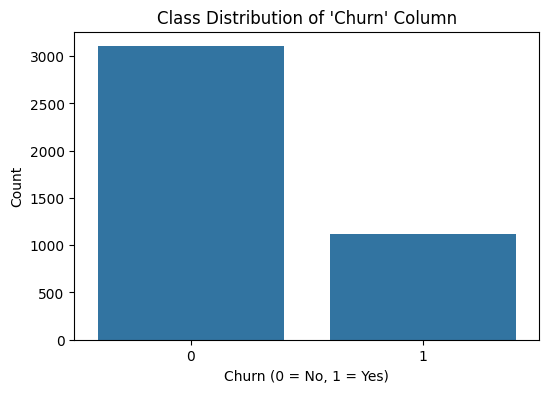

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(data=TrainData, x='Churn')
plt.title("Class Distribution of 'Churn' Column")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

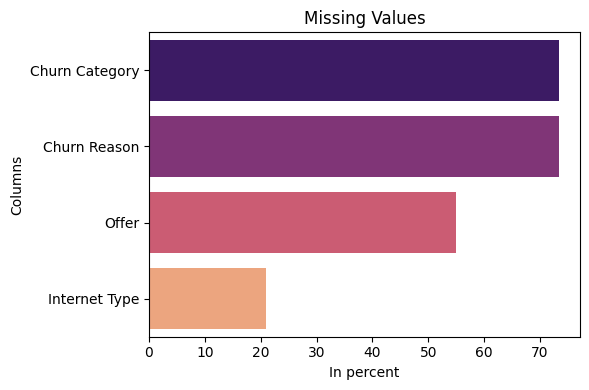

In [6]:
mv = TrainData.isnull().sum()
mp = (mv / len(TrainData)) * 100
ms = pd.DataFrame({
    'col': mv.index,
    'count': mv.values,
    'pct': mp.values
}).sort_values('pct', ascending=False)
ms = ms[ms['count'] > 0]
plt.figure(figsize=(6, 4))
sns.barplot(x='pct', y='col', data=ms, hue='col',  palette='magma',legend=False)
plt.title('Missing Values')
plt.xlabel('In percent')
plt.ylabel('Columns')
plt.tight_layout()
plt.show()

In [7]:
DropCutoff=70

missing = TrainData.isnull().mean() * 100
drop_cols = missing[missing > DropCutoff].index
print(f"Dropped columns : {list(drop_cols)}")
TrainCleanData = TrainData.drop(columns=drop_cols)
TestCleanData = TestData.drop(columns=drop_cols)
ValidationCleanData = ValidationData.drop(columns=drop_cols)
print(TrainCleanData.shape, TestCleanData.shape, ValidationCleanData.shape)

Dropped columns : ['Churn Category', 'Churn Reason']
(4225, 51) (1409, 51) (1409, 51)


In [8]:
DroppedFeatures = ["Online Security", "Senior Citizen","Phone Service","State","Premium Tech Support",
    "Internet Service", "Married", "Under 30","Customer Status","Streaming Music","Internet Type",
    "Gender","Referred a Friend","Total Extra Data Charges","Paperless Billing","Partner",
    "Streaming TV", "Device Protection Plan", "Country","Dependents", "Payment Method",
    "Streaming Movies","Multiple Lines","Offer","Online Backup","Avg Monthly GB Download",
    "Quarter","Total Refunds","Unlimited Data"
]

for col in DroppedFeatures:
    TrainCleanData.drop( columns=col, inplace=True )
    TestCleanData.drop( columns=col, inplace=True )
    ValidationCleanData.drop( columns=col, inplace=True )
print(TrainCleanData.shape, TestCleanData.shape, ValidationCleanData.shape)

(4225, 22) (1409, 22) (1409, 22)


In [9]:
from sklearn.impute import SimpleImputer
import pandas as pd

def get_imputation_values(train_df, cutoff=0.8):
    num_cols = train_df.select_dtypes(include='number').columns
    cat_cols = train_df.select_dtypes(exclude='number').columns
    num_missing = train_df[num_cols].isnull().mean()
    cat_missing = train_df[cat_cols].isnull().mean()
    num_to_impute = num_missing[num_missing <= cutoff].index
    cat_to_impute = cat_missing[cat_missing <= cutoff].index

    impute_values = {
        'median': train_df[num_to_impute].median().to_dict(),
        'mode': train_df[cat_to_impute].mode().loc[0].to_dict()
    }

    return impute_values, num_to_impute, cat_to_impute

def apply_imputation(df, impute_values, num_cols, cat_cols):
    df = df.copy()
    for col in num_cols:
        if col in df.columns and df[col].isna().any():
            df[col] = df[col].fillna(impute_values['median'][col])
    for col in cat_cols:
        if col in df.columns and df[col].isna().any():
            df[col] = df[col].fillna(impute_values['mode'][col])

    return df

impute_values, num_cols, cat_cols = get_imputation_values(TrainCleanData)
ImputedTrainData = apply_imputation(TrainCleanData, impute_values, num_cols, cat_cols)
ImputedTestData = apply_imputation(TestCleanData, impute_values, num_cols, cat_cols)
ImputedValidationData = apply_imputation(ValidationCleanData, impute_values, num_cols, cat_cols)
print("Train data shape:", ImputedTrainData.shape)
print("Test data shape:", ImputedTestData.shape)
print("Validation data shape:", ImputedValidationData.shape)

Train data shape: (4225, 22)
Test data shape: (1409, 22)
Validation data shape: (1409, 22)


In [10]:
def remove_outliers(data, z_thresh=3):
    num_cols = data.select_dtypes(include='number').columns
    z_vals = data[num_cols].apply(lambda col: (col - col.mean()) / col.std() if col.std() != 0 else 0)
    is_outlier = (np.abs(z_vals) > z_thresh).any(axis=1)

    return data[~is_outlier]

ZscoreTrainData = remove_outliers(ImputedTrainData, z_thresh=3)
print(ZscoreTrainData.shape)

(4140, 22)


In [11]:
def get_high_cardinality_cols(train_df, max_unique_values=10):
    categorical_features = train_df.select_dtypes(include=["object"]).columns
    columns_to_drop = []

    for feature in categorical_features:
        unique_count = train_df[feature].nunique()
        if unique_count > max_unique_values:
            print(f"Will remove '{feature}' (has {unique_count} unique values)")
            columns_to_drop.append(feature)

    return columns_to_drop

def remove_columns_by_list(df, columns_to_drop):
    df = df.copy()
    cols_existing = [col for col in columns_to_drop if col in df.columns]
    if cols_existing:
        df.drop(columns=cols_existing, inplace=True)
    return df

cols_to_remove = get_high_cardinality_cols(ZscoreTrainData)
CardinalityTrainData = remove_columns_by_list(ZscoreTrainData, cols_to_remove)
CardinalityTestData = remove_columns_by_list(ImputedTestData, cols_to_remove)
CardinalityValidationData = remove_columns_by_list(ImputedValidationData, cols_to_remove)
print("Train:", CardinalityTrainData.shape)
print("Test:", CardinalityTestData.shape)
print("Validation:", CardinalityValidationData.shape)

Will remove 'City' (has 1078 unique values)
Will remove 'Customer ID' (has 4140 unique values)
Will remove 'Lat Long' (has 1612 unique values)
Train: (4140, 19)
Test: (1409, 19)
Validation: (1409, 19)


In [12]:
categorical_cols = CardinalityTrainData.select_dtypes( include=[ "object" ] ).columns
for col in categorical_cols:
    if CardinalityTrainData[ col ].nunique() > 10:
        CardinalityTrainData.drop( columns=col, inplace=True )
        CardinalityValidationData.drop( columns=col, inplace=True )
        CardinalityTestData.drop( columns=col, inplace=True )

print(len(CardinalityTrainData), len(CardinalityTrainData.columns))
print(len(CardinalityTestData), len(CardinalityTestData.columns))
print(len(CardinalityValidationData), len(CardinalityValidationData.columns))

4140 19
1409 19
1409 19


In [13]:
def encode_data(df):
    cat_features = df.select_dtypes(include=['object', 'category']).columns
    return pd.get_dummies(df, columns=cat_features, drop_first=True, dtype=int )

EncodedTrainData = encode_data(CardinalityTrainData)
print(len(EncodedTrainData), len(EncodedTrainData.columns))
EncodedTestData = encode_data(CardinalityTestData)
print(len(EncodedTestData), len(EncodedTestData.columns))
EncodedValidationData = encode_data(CardinalityValidationData)
print(len(EncodedValidationData), len(EncodedValidationData.columns))

4140 20
1409 20
1409 20


In [14]:
def calculate_monthly_charges(df):
    df = df.copy()
    df['Average Monthly Charges'] = df['Total Charges'] / df['Tenure in Months']
    return df

def normalize_data(train_df, other_dfs=[]):
    train_df = calculate_monthly_charges(train_df)
    processed_dfs = [train_df]
    for df in other_dfs:
        processed_dfs.append(calculate_monthly_charges(df))
    numerical_cols = train_df.select_dtypes(include=["number"]).columns.difference(['Churn'])
    df_mean = train_df[numerical_cols].mean()
    df_std = train_df[numerical_cols].std()
    non_zero_std = df_std[df_std != 0].index
    results = []
    for df in processed_dfs:
        df_norm = df.copy()
        df_norm[numerical_cols] = df_norm[numerical_cols] - df_mean
        df_norm[non_zero_std] = df_norm[non_zero_std] / df_std[non_zero_std]
        results.append(df_norm)
    return results[0] if len(results) == 1 else tuple(results)

NormalizedTrainData, NormalizedValidationData, NormalizedTestData = normalize_data(EncodedTrainData, other_dfs=[EncodedValidationData, EncodedTestData])
print("Train shape:", NormalizedTrainData.shape)
print("Validation shape:", NormalizedValidationData.shape)
print("Test shape:", NormalizedTestData.shape)

Train shape: (4140, 21)
Validation shape: (1409, 21)
Test shape: (1409, 21)


# **بخش دوم : مدل سازی برای پیش بینی ترک اشتراک**

جداسازی نمونه آزمون و آزمایش و ورودی و خروجی آن

In [15]:
x_train = NormalizedTrainData.drop(columns=['Churn'])
y_train = NormalizedTrainData['Churn']
x_valid = NormalizedValidationData.drop(columns=['Churn'])
y_valid = NormalizedValidationData['Churn']
x_test = NormalizedTestData.drop(columns=['Churn'])
y_test = NormalizedTestData['Churn']

print(x_train.shape, y_train.shape, x_test.shape, y_test.shape, x_valid.shape, y_valid.shape)

(4140, 20) (4140,) (1409, 20) (1409,) (1409, 20) (1409,)


الگوریتم پایه الجستیک رگرسیون بدون استفاده از توابع آماده

In [18]:
import numpy as np

def logistic_regression(x_train, y_train, x_test):
    coeffs = np.zeros(x_train.shape[1])
    cost_history = []

    z = x_train @ coeffs
    prob = 1 / (1 + np.exp(-z))
    initial_cost = -np.mean(y_train * np.log(prob) + (1 - y_train) * np.log(1 - prob))
    cost_history.append(initial_cost)

    for i in range(1000):
        z = x_train @ coeffs
        prob = 1 / (1 + np.exp(-z))
        error = prob - y_train
        gradient = x_train.T @ error / len(y_train)
        coeffs -= 0.1 * gradient
        z = x_train @ coeffs
        prob = 1 / (1 + np.exp(-z))
        current_cost = -np.mean(y_train * np.log(prob) + (1 - y_train) * np.log(1 - prob))
        cost_history.append(current_cost)
        if len(cost_history) > 1 and abs(cost_history[-2] - cost_history[-1]) < 1e-6:
            break

    test_z = x_test @ coeffs
    test_prob = 1 / (1 + np.exp(-test_z))
    predictions = (test_prob > 0.5).astype(int)

    return predictions, test_prob, coeffs, cost_history

predictions, probabilities, coeffs, cost_history = logistic_regression(x_train, y_train, x_test)
accuracy = np.mean(predictions == y_test.values)
print(f'Test accuracy: {accuracy:.4f}')
print(f'Final weights: {coeffs}')

Test accuracy: 0.8666
Final weights: Unnamed: 0                           0.059430
Age                                  0.187519
Avg Monthly Long Distance Charges   -0.061644
Churn Score                          1.211542
CLTV                                 0.058400
Latitude                            -0.043890
Longitude                            0.006632
Monthly Charge                       0.251487
Number of Dependents                -0.160858
Number of Referrals                 -0.186215
Population                           0.106374
Satisfaction Score                  -2.454108
Tenure in Months                    -0.128451
Total Charges                       -0.363547
Total Long Distance Charges          0.137862
Total Revenue                       -0.247458
Zip Code                             0.059197
Contract_One Year                   -0.315769
Contract_Two Year                   -0.337130
Average Monthly Charges              0.229708
dtype: float64


گزارش تحلیلی نتایج برپایه درخواست های مطرح شده در پرسش


Classification Report:
               Class 0        Class 1        
Precision      0.9988        0.6661
Recall         0.8193        0.9973
F1-Score       0.9002        0.7987
Support        1035           374            

ROC AUC: 0.9965


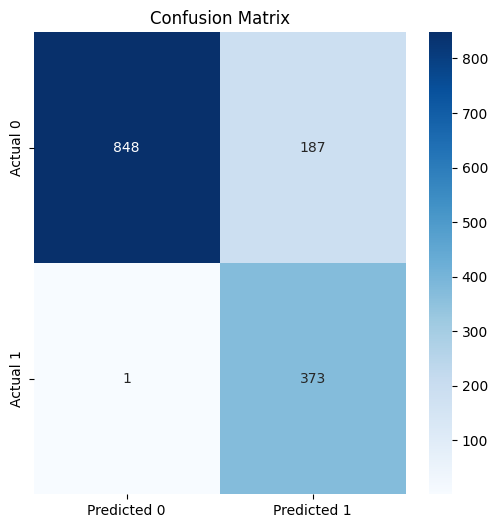

In [19]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def roc_curve(y_true, probas):
    thresholds = np.sort(np.unique(probas))[::-1]
    tpr = []
    fpr = []
    for thresh in thresholds:
        y_pred = (probas >= thresh).astype(int)
        TP = np.sum((y_true == 1) & (y_pred == 1))
        FP = np.sum((y_true == 0) & (y_pred == 1))
        TN = np.sum((y_true == 0) & (y_pred == 0))
        FN = np.sum((y_true == 1) & (y_pred == 0))
        tpr_val = TP / (TP + FN) if (TP + FN) > 0 else 0
        fpr_val = FP / (FP + TN) if (FP + TN) > 0 else 0
        tpr.append(tpr_val)
        fpr.append(fpr_val)

    return np.array(fpr), np.array(tpr), thresholds

def auc(fpr, tpr):
    area = 0
    for i in range(1, len(fpr)):
        dx = fpr[i] - fpr[i-1]
        avg_height = (tpr[i] + tpr[i-1]) / 2
        area += dx * avg_height
    return area

def class_report(y_true, y_pred, probas):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    precision_1 = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall_1 = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_1 = 2 * (precision_1 * recall_1) / (precision_1 + recall_1) if (precision_1 + recall_1) > 0 else 0
    precision_0 = TN / (TN + FN) if (TN + FN) > 0 else 0
    recall_0 = TN / (TN + FP) if (TN + FP) > 0 else 0
    f1_0 = 2 * (precision_0 * recall_0) / (precision_0 + recall_0) if (precision_0 + recall_0) > 0 else 0
    support_1 = np.sum(y_true == 1)
    support_0 = np.sum(y_true == 0)
    fpr, tpr, _ = roc_curve(y_true, probas)
    roc_auc = auc(fpr, tpr)
    print("\nClassification Report:")
    print(f"{'':<15}{'Class 0':<15}{'Class 1':<15}")
    print(f"{'Precision':<15}{precision_0:.4f}{'':<8}{precision_1:.4f}")
    print(f"{'Recall':<15}{recall_0:.4f}{'':<8}{recall_1:.4f}")
    print(f"{'F1-Score':<15}{f1_0:.4f}{'':<8}{f1_1:.4f}")
    print(f"{'Support':<15}{support_0:<15}{support_1:<15}")
    print(f"\nROC AUC: {roc_auc:.4f}")

    conf_matrix = np.array([[TN, FP], [FN, TP]])
    plt.figure(figsize=(6, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title('Confusion Matrix')
    plt.show()

    return {
        'class_0': {'precision': precision_0, 'recall': recall_0, 'f1': f1_0, 'support': support_0},
        'class_1': {'precision': precision_1, 'recall': recall_1, 'f1': f1_1, 'support': support_1},
        'auc': roc_auc
    }


test_prob = sigmoid(x_test @ coeffs)
predictions = (test_prob > 0.5).astype(int)
report = class_report(y_test, predictions, test_prob)


استفاده از کتابخانه زیر برای متوازن کردن داده ورودی

In [23]:
!pip install imbalanced-learn

In [24]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_train_balanced, y_train_balanced = smote.fit_resample(x_train, y_train)

اعمال الگوریتم لاجستیک رگرسیون ساخته شده در این تمرین با داده متوازن شده

In [25]:
predictions, probabilities, coeffs, cost_history = logistic_regression(x_train_balanced, y_train_balanced, x_test)
accuracy = np.mean(predictions == y_test.values)
print(f'Test accuracy: {accuracy:.4f}')

Test accuracy: 0.8659


پیاده سازی الگوریتم لاجستیک رگرسیون با وزن دهی کلاس

In [27]:
import numpy as np

def logistic_regression_with_weights(x_train, y_train, x_test, class_weight, learning_rate=0.1, max_iter=1000):
    coeffs = np.zeros(x_train.shape[1])
    cost_history = []
    sample_weights = np.array([class_weight[0] if y == 0 else class_weight[1] for y in y_train])
    z = x_train @ coeffs
    prob = 1 / (1 + np.exp(-z))
    cost = -np.mean(sample_weights * (y_train * np.log(prob + 1e-15) + (1 - y_train) * np.log(1 - prob + 1e-15)))
    cost_history.append(cost)

    for i in range(max_iter):
        z = x_train @ coeffs
        prob = 1 / (1 + np.exp(-z))
        error = sample_weights * (prob - y_train)
        gradient = x_train.T @ error / len(y_train)

        coeffs -= learning_rate * gradient
        current_cost = -np.mean(sample_weights * (y_train * np.log(prob + 1e-15) + (1 - y_train) * np.log(1 - prob + 1e-15)))
        cost_history.append(current_cost)
    test_z = x_test @ coeffs
    test_prob = 1 / (1 + np.exp(-test_z))
    predictions = (test_prob > 0.5).astype(int)
    return {
        'predictions': predictions,
        'probabilities': test_prob,
        'coefficients': coeffs,
        'cost_history': cost_history
    }

class_counts = np.bincount(y_train)
total_samples = len(y_train)
weight_for_0 = total_samples / (2 * class_counts[0])
weight_for_1 = total_samples / (2 * class_counts[1])
class_weight = {0: weight_for_0, 1: weight_for_1}

results = logistic_regression_with_weights(
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    class_weight=class_weight,
    learning_rate=0.1,
    max_iter=1000
)

# Evaluate
accuracy = np.mean(results['predictions'] == y_test.values)
print(f'Test accuracy: {accuracy:.4f}')
print(f'Final weights: {results["coefficients"]}')

Test accuracy: 0.8666
Final weights: Unnamed: 0                           0.069633
Age                                  0.186846
Avg Monthly Long Distance Charges   -0.046052
Churn Score                          1.357348
CLTV                                 0.043787
Latitude                            -0.043515
Longitude                            0.010014
Monthly Charge                       0.237786
Number of Dependents                -0.191336
Number of Referrals                 -0.227567
Population                           0.099843
Satisfaction Score                  -2.500290
Tenure in Months                    -0.174403
Total Charges                       -0.305959
Total Long Distance Charges          0.097798
Total Revenue                       -0.213487
Zip Code                             0.053432
Contract_One Year                   -0.316063
Contract_Two Year                   -0.364828
Average Monthly Charges              0.217314
dtype: float64


استفاده از کتابخانه آماده برای پیاده سازی لاجستیک رگرسیون پایه، متوازن شده و با کلاس وزن دار و مشاهده نتایج آن

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
clf = LogisticRegression()
print('unbalanced report')
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)
accuracy = clf.score(x_test, y_test)
print(f"Model accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

print('balanced report')
clf.fit(x_train_balanced, y_train_balanced)
y_pred = clf.predict(x_test)
accuracy = clf.score(x_test, y_test)
print(f"Model accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

print("custom weighted report")
class_counts = np.bincount(y_train)
total_samples = len(y_train)
weight_for_0 = total_samples / (2 * class_counts[0])
weight_for_1 = total_samples / (2 * class_counts[1])
class_weight = {0: weight_for_0, 1: weight_for_1}
clf_custom = LogisticRegression(class_weight=class_weight, max_iter=1000)
clf_custom.fit(x_train, y_train)
y_pred_custom = clf_custom.predict(x_test)
print(f"Model accuracy: {clf_custom.score(x_test, y_test):.4f}")
print(classification_report(y_test, y_pred_custom))

unbalanced report
Model accuracy: 0.9730
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1035
           1       0.96      0.94      0.95       374

    accuracy                           0.97      1409
   macro avg       0.97      0.96      0.97      1409
weighted avg       0.97      0.97      0.97      1409

balanced report
Model accuracy: 0.9674
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1035
           1       0.93      0.95      0.94       374

    accuracy                           0.97      1409
   macro avg       0.96      0.96      0.96      1409
weighted avg       0.97      0.97      0.97      1409

custom weighted report
Model accuracy: 0.9652
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1035
           1       0.92      0.95      0.94       374

    accuracy                           0.97      1409
  